# Data Analysis and Figures
Author: Joshua Holmes <br>
Email: jbh92@case.edu <br>

The following notebook replicates all the data analysis and figure generation used in the study, "Drag Racers and Long Haulers: The Design Space of myosin-V-lke Motor Protiens" by Joshua Holmes and Michael Hinczewski.

# Imports and Global Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

import myo5space.fitting as fitting
import myo5space.figures as figures
from myo5space.motor import Motor

In [2]:
column_width = 3.375 # Inches

path_figures = Path.cwd()
path_fitdata = Path.cwd().joinpath('FittingData')
path_figdata = Path.cwd().joinpath('FigureData')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['legend.frameon'] = False

In [3]:
def find_text_ypos(fig, axes):
    res = list()
    renderer = fig.canvas.get_renderer()
    for ax in axes:
        tight_bbox = ax.get_tightbbox(renderer)
        tight_bbox_fig = tight_bbox.transformed(fig.transFigure.inverted())
        y_top = tight_bbox_fig.y1
        res.append(y_top)
    # res = max(res)
    return res


def label_subplots(fig, axes, start=0):
    fig.canvas.draw()

    renderer = fig.canvas.get_renderer()
    y_top = find_text_ypos(fig, axes)

    for i, ax in enumerate(axes.ravel()):
        label = f"({chr(97 + i + start)})"

        tight_bbox = ax.get_tightbbox(renderer)
        tight_bbox_fig = tight_bbox.transformed(fig.transFigure.inverted())

        x_left = tight_bbox_fig.x0

        pad = 0.01

        t = fig.text(
            x_left - pad,
            y_top[i],
            label,
            ha="left",
            va="top",
            fontsize="large",
        )
        if hasattr(t, "set_in_layout"):
            t.set_in_layout(False)
    return None

# Fitting to Experimental Data
Here we attempt to compare the model to optical trap data collected from Nicotiana tabacum Myosin-XI (MyoXI) by Tominaga et. al. 2003.

## Methods
The experimental setup consisted of a compliant optical trap that records displacement of a single motor conected via a polystyrene bead as it runs along f-actin. The stiffness of the trap was set to 4.7 fN/nm while the stiffness of the motor-bead linkage was estimated to be between 21 and 120 fN/nm. Considering that these stiffnesses act in series, the overall stiffness is calculated to be between 3.8 and 4.4 fN/nm. We thus used the mid-stiffness value of 4.1 fN/nm for our comparisions.

Two elements of MyoXI dynamics were considered for comparions to the model: the distribution of dwell times, defined as the time the motor stays at one position, and the distribution of forces at the motor's detachment from f-actin. Tominaga2003 reports these distributions for ATP concentrations of 1 and 100 uM.

## Data loading and preprocessing

In [4]:
# Dictionaries with fitting scores to individual datasets.
scores_2free = fitting.load_scores(
    path_fitdata.joinpath("kd1kd2"),
    fitting.get_myoXI_stepsize(),
    fitting.get_expvel_mean(),
    fitting.get_expvel_std(),
)
scores_4free = fitting.load_scores(
    path_fitdata.joinpath("kd1kd2nucthetac"),
    fitting.get_myoXI_stepsize(),
    fitting.get_expvel_mean(),
    fitting.get_expvel_std(),
)

# Combinded fitting scores.
score_2free = fitting.combine_all_scores(scores_2free)
score_4free = fitting.combine_all_scores(scores_4free)

## Results: kd1 and kd2 as free parameters

In [5]:
bestfit_inds_2free, bestfit_args_2free = fitting.find_bestfit_args_2free(score_2free)

Best fit parameters
     kd2: 5.738e+00 1/s
     kd1 1uM: 5.053e-01 1/s
     kd1 100uM: 2.933e+02 1/s



In [6]:
maxscore_2free = score_2free[bestfit_inds_2free]
print(f'{maxscore_2free = }')

maxscore_2free = -2651.724029215923


In [7]:
bestfit_inds_2free

(70, 28, 138)

In [8]:
bestvrun_2free = fitting.find_bestfit_vrun(
    # Exclude the kd1 1um index.
    scores_2free.get("vrun100um_vals"), bestfit_inds_2free[::2]
)
print(f"{bestvrun_2free = } um/s")

bestvrun_2free = 6.798999633754362 um/s


## Results: kd1, kd2, thetac, and nuc, as free parameters

In [9]:
bestfit_inds_4free, bestfit_args_4free = fitting.find_bestfit_args_4free(score_4free)

Best fit parameters
     ThetaC: 5.778e-01 rad
     nuC: 2.466e+02 
     kd2: 5.736e+01 1/s
     kd1 1uM: 1.083e+00 1/s
     kd1 100uM: 1.887e+02 1/s



In [10]:
maxscore_4free = score_4free[bestfit_inds_4free]
print(f'{maxscore_4free = }')

maxscore_4free = -2422.4303956742024


In [11]:
bestvrun_4free = fitting.find_bestfit_vrun(
    # Exclude the kd1 1um index.
    scores_4free.get("vrun100um_vals"), bestfit_inds_4free[:-2] + bestfit_inds_4free[-1:]
)
print(f"{bestvrun_4free = } um/s")

bestvrun_4free = 4.378844418073755 um/s


## Plots of best fits

In [12]:
motor_2free1um, motor_2free100um, motor_4free1um, motor_4free100um = (
    figures.make_bestfit_motors(bestfit_args_2free, bestfit_args_4free)
)

In [10]:
if not figures.check_bestfitplot_data(path_figdata):
    figures.make_bestfitplot_data(
        path_figdata, motor_2free1um, motor_2free100um, motor_4free1um, motor_4free100um
    )

In [11]:
hist_df = pd.read_csv(path_figdata.joinpath("bestfitplot_histdata.csv"))
pdf_df = pd.read_csv(path_figdata.joinpath("bestfitplot_pdfdata.csv"))

In [ ]:
if not figures.check_bestfitforce_data(path_figdata):
    figures.make_bestfitforce_data(
        path_figdata, motor_2free100um, motor_4free100um
    )

In [ ]:
bestfitforce_df = pd.read_csv(path_figdata.joinpath('bestfitforce_data.csv'))

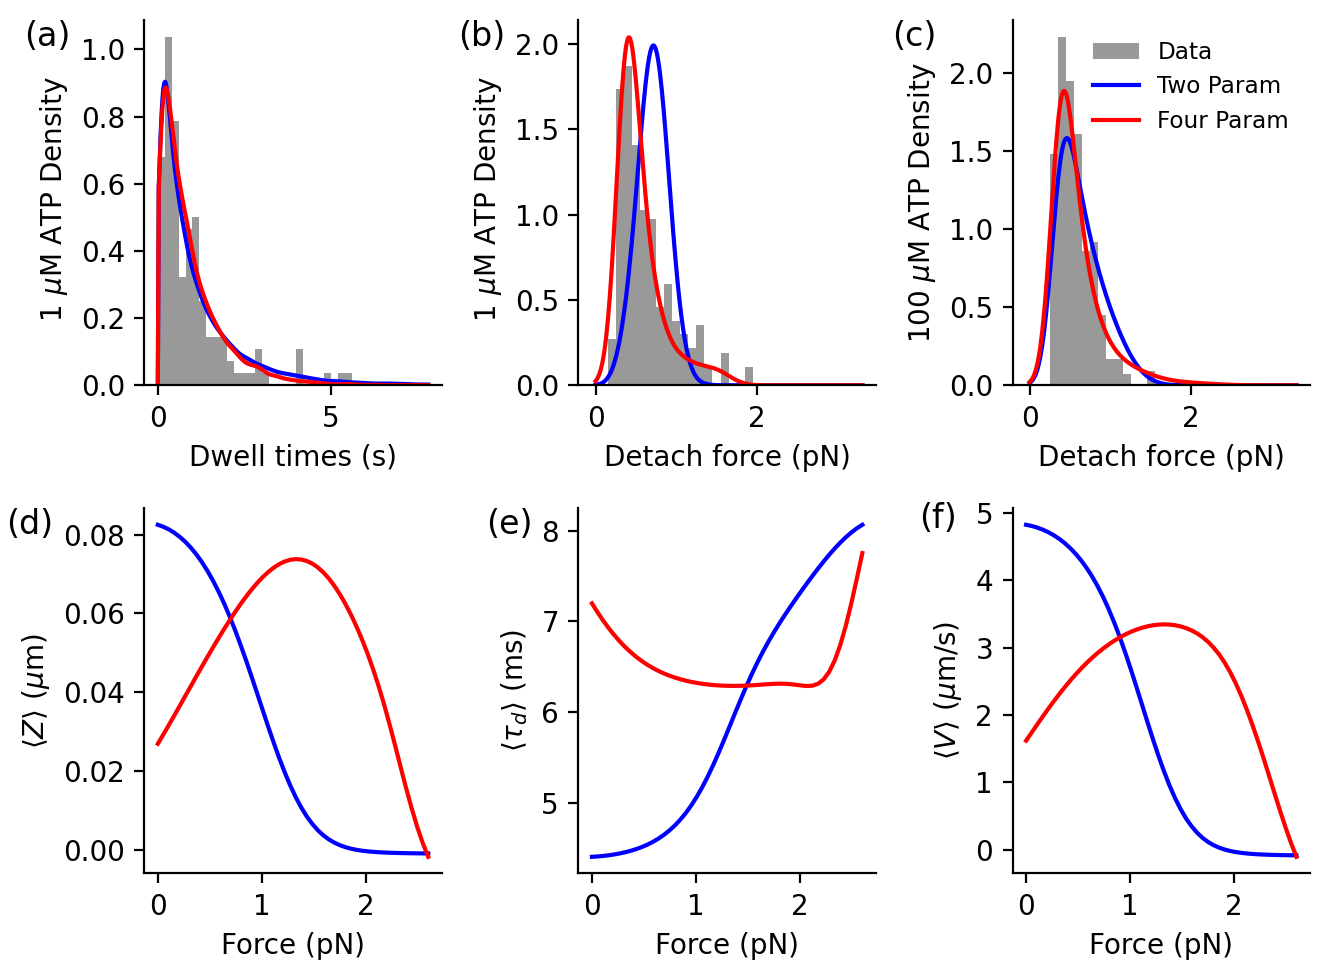

In [ ]:
hist_alpha = 0.8
hist_label = "Data"
hist_color = "grey"

color_2free = "blue"
color_4free = "red"

label_2free = "Two Param"
label_4free = "Four Param"

fig, axs = plt.subplots(2, 3, figsize=(2 * column_width, 5))
axs = axs.flatten()

# 1um dwell times
ax = axs[0]
ax.hist(
    hist_df.bins_dwell1um.dropna().iloc[:-1],
    bins=hist_df.bins_dwell1um.dropna(),
    weights=hist_df.counts_dwell1um.dropna(),
    color=hist_color,
    alpha=hist_alpha,
    density=True,
)
ax.plot(pdf_df.x_dwell_2free1um, pdf_df.y_dwell_2free1um, color=color_2free)
ax.plot(pdf_df.x_dwell_4free1um, pdf_df.y_dwell_4free1um, color=color_4free)

# ax.set_title("1 $\mu$M ATP", fontsize="medium")
ax.set_xlabel("Dwell times (s)")
ax.set_ylabel(" 1 $\mu$M ATP Density")

# 1um detachmnet forces
ax = axs[1]
ax.hist(
    hist_df.bins_detach1um.dropna().iloc[:-1],
    bins=hist_df.bins_detach1um.dropna(),
    weights=hist_df.counts_detach1um.dropna(),
    color=hist_color,
    alpha=hist_alpha,
    density=True,
)

ax.plot(pdf_df.x_detach_2free1um, pdf_df.y_detach_2free1um, color=color_2free)
ax.plot(pdf_df.x_detach_4free1um, pdf_df.y_detach_4free1um, color=color_4free)

# ax.set_title("1 $\mu$M ATP", fontsize="medium")
ax.set_xlabel("Detach force (pN)")
ax.set_ylabel(" 1 $\mu$M ATP Density")

# 100um detachmnet forces
ax = axs[2]
counts, bins = fitting.get_expdata("detach 100um")
ax.hist(
    hist_df.bins_detach100um.dropna().iloc[:-1],
    bins=hist_df.bins_detach100um.dropna(),
    weights=hist_df.counts_detach100um.dropna(),
    color=hist_color,
    alpha=hist_alpha,
    density=True,
    label=hist_label,
)
ax.plot(
    pdf_df.x_detach_2free100um,
    pdf_df.y_detach_2free100um,
    color=color_2free,
    label=label_2free,
)
ax.plot(
    pdf_df.x_detach_4free100um,
    pdf_df.y_detach_4free100um,
    color=color_4free,
    label=label_4free,
)

ax.legend(fontsize="small")
# ax.set_title("100 $\mu$M ATP", fontsize="medium")
ax.set_xlabel("Detach force (pN)")
ax.set_ylabel("100 $\mu$M ATP Density")

ax = axs[3]
ax.plot(bestfitforce_df.forces, bestfitforce_df.zruns_2free100um, color=color_2free)
ax.plot(bestfitforce_df.forces, bestfitforce_df.zruns_4free100um, color=color_4free)
ax.set_xlabel("Force (pN)")
ax.set_ylabel(r"$\left<Z\right>$ ($\mu$m)")
# ax.set_ylim(bottom=0.025, top=0.11)

ax = axs[4]
ax.plot(
    bestfitforce_df.forces, 1000 * bestfitforce_df.tdwells_2free100um, color=color_2free
)
ax.plot(
    bestfitforce_df.forces, 1000 * bestfitforce_df.tdwells_4free100um, color=color_4free
)
ax.set_xlabel("Force (pN)")
ax.set_ylabel(r"$\left<\tau_d\right>$ (ms)")
# ax.set_ylim(bottom=5.9, top=8.1)

ax = axs[5]
ax.plot(
    bestfitforce_df.forces,
    bestfitforce_df.vruns_2free100um,
    color=color_2free,
    label=label_2free,
)
ax.plot(
    bestfitforce_df.forces,
    bestfitforce_df.vruns_4free100um,
    color=color_4free,
    label=label_4free,
)
ax.set_xlabel("Force (pN)")
ax.set_ylabel(r"$\left<V\right>$ ($\mu$m/s)")

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath("bestfitplot_results.pdf"), facecolor="w")
plt.show()

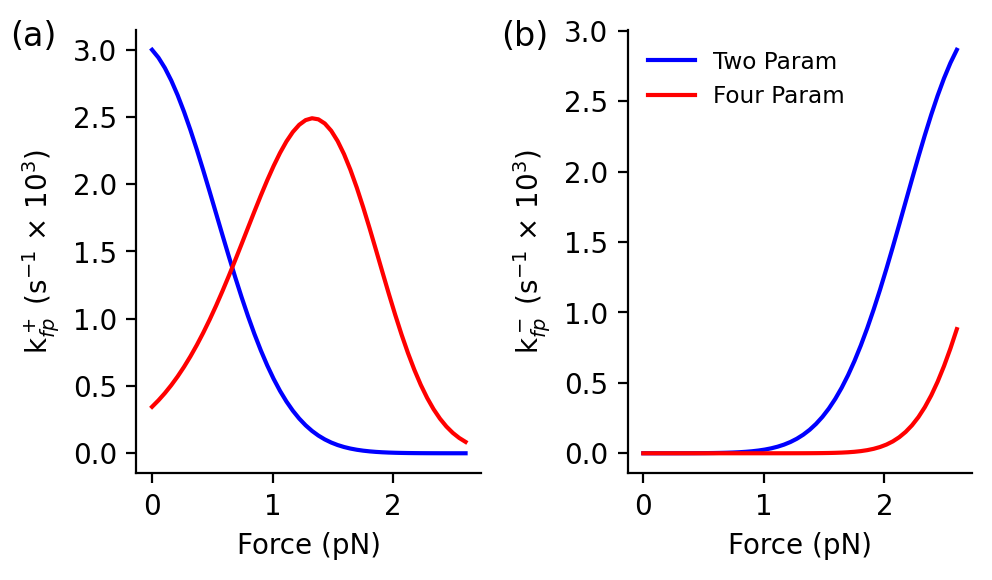

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(1.5*column_width, 3))
axs = axs.flatten()

ax = axs[0]
ax.plot(bestfitforce_df.forces, bestfitforce_df.kfpps_2free100um/1000, color=color_2free)
ax.plot(bestfitforce_df.forces, bestfitforce_df.kfpps_4free100um/1000, color=color_4free)
ax.set_xlabel('Force (pN)')
ax.set_ylabel(r'k$_{fp}^+$ (s$^{-1}$ $\times$ $10^3$)')

ax = axs[1]
ax.plot(bestfitforce_df.forces, bestfitforce_df.kfpms_2free100um/1000, color=color_2free, label=label_2free)
ax.plot(bestfitforce_df.forces, bestfitforce_df.kfpms_4free100um/1000, color=color_4free, label=label_4free)
ax.legend(fontsize='small')
ax.set_xlabel('Force (pN)')
ax.set_ylabel(r'k$_{fp}^-$ (s$^{-1}$ $\times$ 10$^3$)')

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath('bestfitkfp.pdf'), facecolor='w')
plt.show()

## Simulated trajectories

In [16]:
if not figures.check_simtraces_data(path_figdata):
    figures.make_simtraces_data(path_figdata, Motor(), motor_4free100um)

In [17]:
simtraces_df = pd.read_csv(path_figdata.joinpath('simtraces_data.csv'), index_col=0)
myoV_times = simtraces_df['MyoV Time (s)']
myoV_disps = simtraces_df['MyoV Disp (um)']
myoXI_times = simtraces_df['MyoXI Time (s)']
myoXI_disps = simtraces_df['MyoXI Disp (um)']

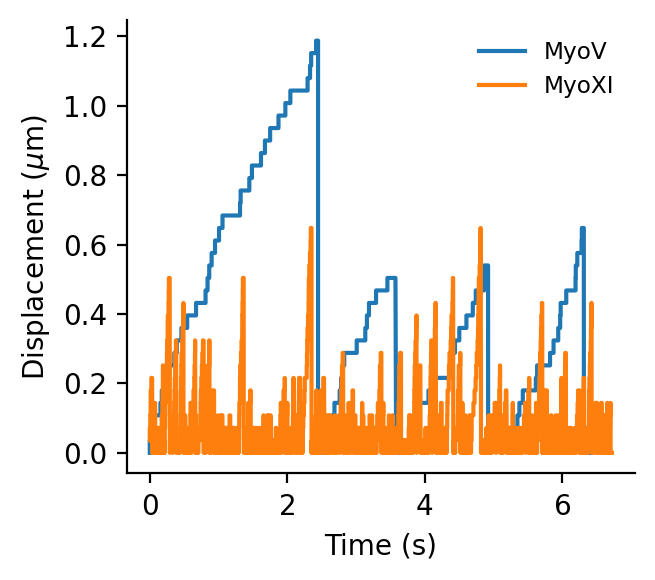

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(column_width, 3))
ax.plot(myoV_times, myoV_disps, label='MyoV')
ax.plot(myoXI_times, myoXI_disps, label="MyoXI")
ax.legend(fontsize='small', loc=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement ($\mu$m)')
plt.tight_layout()
# plt.savefig('traces.png', dpi=300)
plt.show()

# Gamma Approximation of the Dwell Time Distribution

Approximating the dwell time distribution with a gamma distribution is a key mathematical tool used in deriving the various relationships involving the run velocity. To validate its efficacy, the true and approximate distributions for a wide range of motors with various kd1, kd2, kh, kfpp, and kfpm rates are compared against each other using the Kullback-Leibler divergence (KLD). Three constraints are imposed on the rates for a given motor: kd1 > kd2 and 5000 > kfpp > kfpm. These improve the numerical stability of the integration need to calculate the KLD.

In [37]:
if not figures.check_gammaapprox_data(path_figdata):
    figures.make_gammaapprox_data(path_figdata)

In [38]:
gammaapprox_shapekld_df = pd.read_csv(path_figdata.joinpath('gammaapprox_shapekld_data.csv'))
gammaapprox_worst_df = pd.read_csv(path_figdata.joinpath('gammaapprox_worst_data.csv'))

/tmp/ipykernel_1668331/3660979000.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels())
/tmp/ipykernel_1668331/3660979000.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_yticklabels)


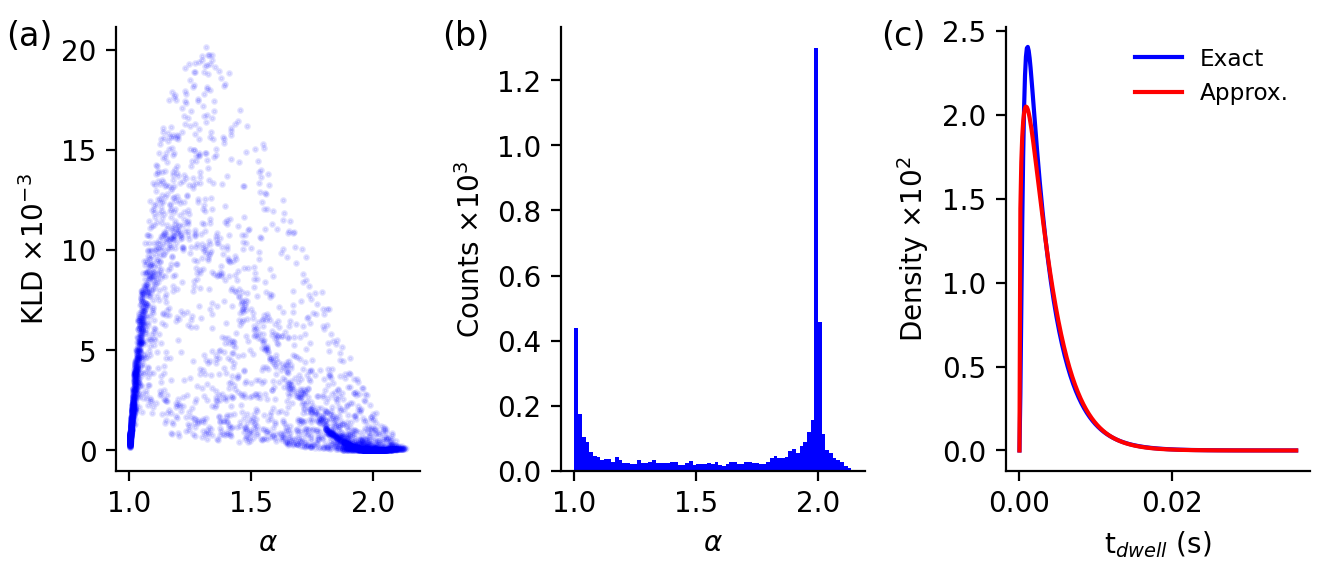

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(2*column_width, 3), dpi=200)
axs = axs.flatten()
ax = axs[0]
ax.scatter(gammaapprox_shapekld_df.shapes, gammaapprox_shapekld_df.klds*1000, s=2, color='blue', alpha=0.1)
ax.set_ylabel(r'KLD $\times 10^{-3}$')
ax.set_xlabel(r'$\alpha$')

ax = axs[1]
ax.hist(gammaapprox_shapekld_df.shapes, bins=75, color='blue')
ax.set_yticklabels(ax.get_yticklabels())
new_yticklabels = [str(label.get_position()[1]/1000) for label in ax.get_yticklabels()]
ax.set_yticklabels(new_yticklabels)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'Counts $\times 10^3$')

ax = axs[2]
ax.plot(gammaapprox_worst_df.tdwells, gammaapprox_worst_df.true_pdf/100, label='Exact', color='blue')
ax.plot(gammaapprox_worst_df.tdwells, gammaapprox_worst_df.approx_pdf/100, label='Approx.', color='red')
ax.set_xlabel('t$_{dwell}$ (s)')
ax.set_ylabel(r'Density $\times 10^2$')
ax.legend(fontsize='small')

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath('gammaapprox.pdf'), facecolor='w')
plt.show()

# The kd1* - kh Square-Root Relationship

A relationship between kd1 and needs to be determined to calculate the maximum average run velocity analytically. The code below numerically determines the kd1 that maximizes the run velocity of a motor with a given kh (kd1*). Since we are interested in the maximum average run velocity, these motors have kd2 = 0 and run under zero force. The resulting points (kh, kd1*) are then fitted to a power-law relationship.

In [24]:
if not figures.check_kd1khline_data(path_figdata):
    figures.make_kd1khline_data(path_figdata)

In [25]:
kd1khline_myoV_df = pd.read_csv(path_figdata.joinpath('kd1khline_myoV_data.csv'))
kd1khline_lines_df = pd.read_csv(path_figdata.joinpath('kd1khline_lines_data.csv'))
kd1khline_shapes_df = pd.read_csv(path_figdata.joinpath('kd1khline_shapes_data.csv'))

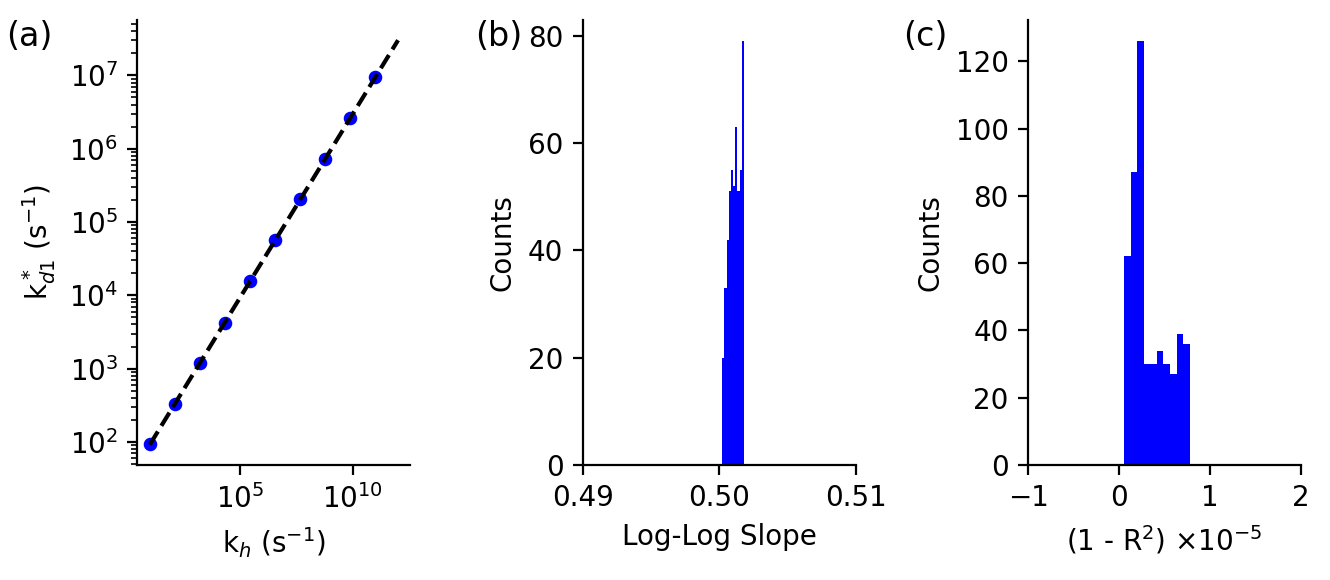

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(2 * column_width, 3), dpi=200)
axs = axs.flatten()

ax = axs[0]
ax.scatter(kd1khline_myoV_df.khs[::10], kd1khline_myoV_df.myoV_vkh[::10], color="blue", s=15)
ax.plot(
    kd1khline_myoV_df.khs,
    kd1khline_myoV_df.khs ** kd1khline_lines_df.slopes.iloc[-1] * 10 ** kd1khline_lines_df.intercepts.iloc[-1],
    ls="--",
    color="black",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k$_h$ (s$^{-1}$)")
ax.set_ylabel(r"k$_{d1}^*$ (s$^{-1}$)")

ax = axs[1]
ax.hist(kd1khline_lines_df.slopes, bins=10, color="blue")
ax.set_xlabel(r"Log-Log Slope")
ax.set_ylabel(r"Counts")
ax.set_xlim(0.49, 0.51)

ax = axs[2]
ax.hist((1 - kd1khline_lines_df.rvals) * 1e5, bins=10, color="blue")
ax.set_xlabel(r"(1 - R$^2$) $\times 10^{-5}$")
ax.set_ylabel(r"Counts")
ax.set_xlim(-1, 2)

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath("kd1khlines.pdf"), facecolor="w")
plt.show()

/tmp/ipykernel_1142275/3932930149.py:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels())
/tmp/ipykernel_1142275/3932930149.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_yticklabels)


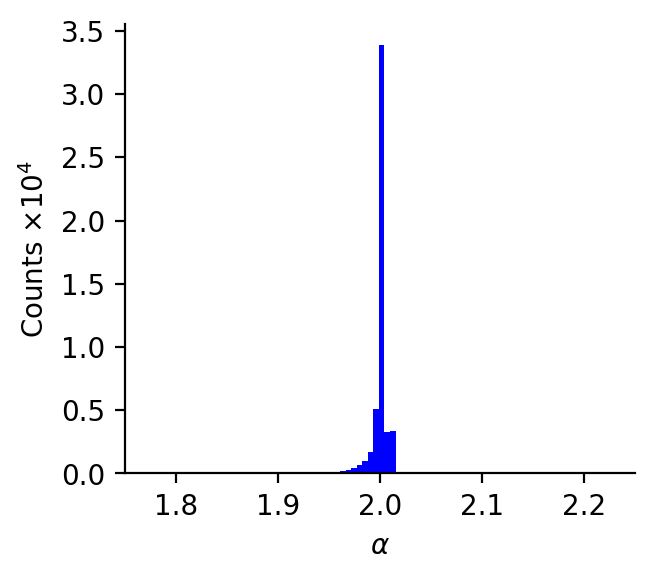

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(column_width, 3), dpi=200)

ax.hist(kd1khline_shapes_df.shapes, bins=12, color='blue')
ax.set_yticklabels(ax.get_yticklabels())
new_yticklabels = [str(label.get_position()[1]/10000) for label in ax.get_yticklabels()]
ax.set_yticklabels(new_yticklabels)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'Counts $\times 10^4$')
ax.set_xlim(1.75, 2.25)

plt.tight_layout()
plt.savefig(path_figures.joinpath('kd1khline_shapes.pdf'), facecolor='w')
plt.show()

# Validating the Speed Limit

The results show that all points (kfpp, average run velocity) lay beneath the line kfpp/3, validating the analytically derived speed limit. The points are also color-coded based on their approximating shape parameter. Notably, there are fast motors with shape parameters of around one, but all the motors nearest to the speed limit have shape parameters closer to two. 

As in the previous section, we also plot the average run velocity only from productive runs. Here, several motors broke the speed limit. All of the motors that do so also have shape parameters of around two.

In [26]:
if not figures.check_speedlimit_data(path_figdata):
    figures.make_speedlimit_data(path_figdata)

In [27]:
speedlimit_df = pd.read_csv(path_figdata.joinpath('speedlimit_data.csv'))

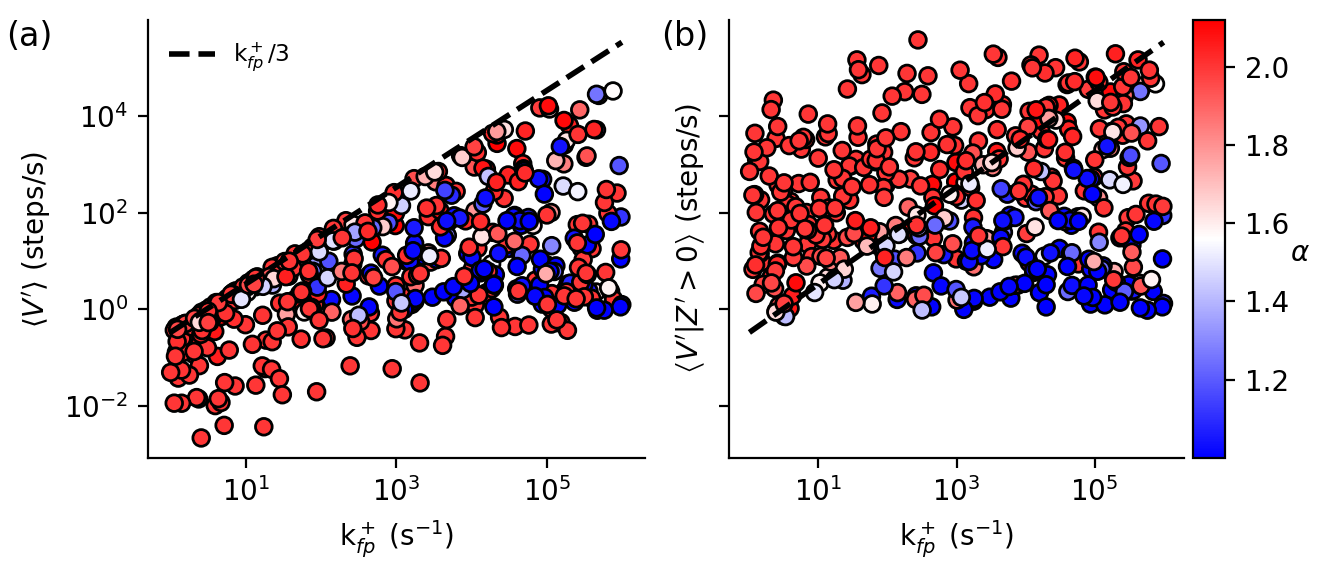

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(column_width * 2, 3), sharey=True)

axs = axs.flatten()
line = np.logspace(0, 6, 100)
axs[0].plot(line, line / 3, c="k", ls="--", lw=2, label=r"k$_{fp}^+$/3")
axs[0].scatter(
    speedlimit_df.kfpp, speedlimit_df.vrun, c=speedlimit_df['shape'], cmap="bwr", ec="k"
)

axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].legend(fontsize="small")
axs[0].set_xlabel("k$_{fp}^+$ (s$^{-1}$)")
axs[0].set_ylabel(r"$\left<V^{\prime}\right>$ (steps/s)")


axs[1].plot(line, line / 3, c="k", lw=2, ls="--")
c1 = axs[1].scatter(
    speedlimit_df.kfpp,
    speedlimit_df.vrun_productive,
    c=speedlimit_df['shape'],
    cmap="bwr",
    ec="k",
)
ax1_divider = make_axes_locatable(axs[1])
cax1 = ax1_divider.append_axes("right", size="7%", pad="2%")
cbar1 = fig.colorbar(c1, cax=cax1, orientation="vertical")
# cax1.xaxis.set_ticks_position('top')
cbar1.set_label(r"$\alpha$", rotation="horizontal")
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("k$_{fp}^+$ (s$^{-1}$)")
axs[1].set_ylabel(r"$\left<V^{\prime}|Z^{\prime} > 0\right>$ (steps/s)")
axs[1].minorticks_off()

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath("speedlimit.pdf"), facecolor="w")
plt.show()

# Validating the Pareto Frontier #

A key finding from this study is the inherent tradeoff between average run distance and average run velocity. To validate the Pareto frontier that describes the fastest run velocity a motor with a given run distance can achieve, we plot average run distance versus average run velocity for motors with a wide range of kd1s and khs, leaving kd2 = 0 and kfpp and kfpm as the values for myosin-V under zero force. The points are also color-coded according to their approximating shape parameter.

In [22]:
if not figures.check_pareto_data(path_figdata):
    figures.make_pareto_data(path_figdata)

In [23]:
pareto_line_df = pd.read_csv(path_figdata.joinpath('pareto_line_data.csv'))
pareto_vz_df = pd.read_csv(path_figdata.joinpath('pareto_vz_data.csv'))

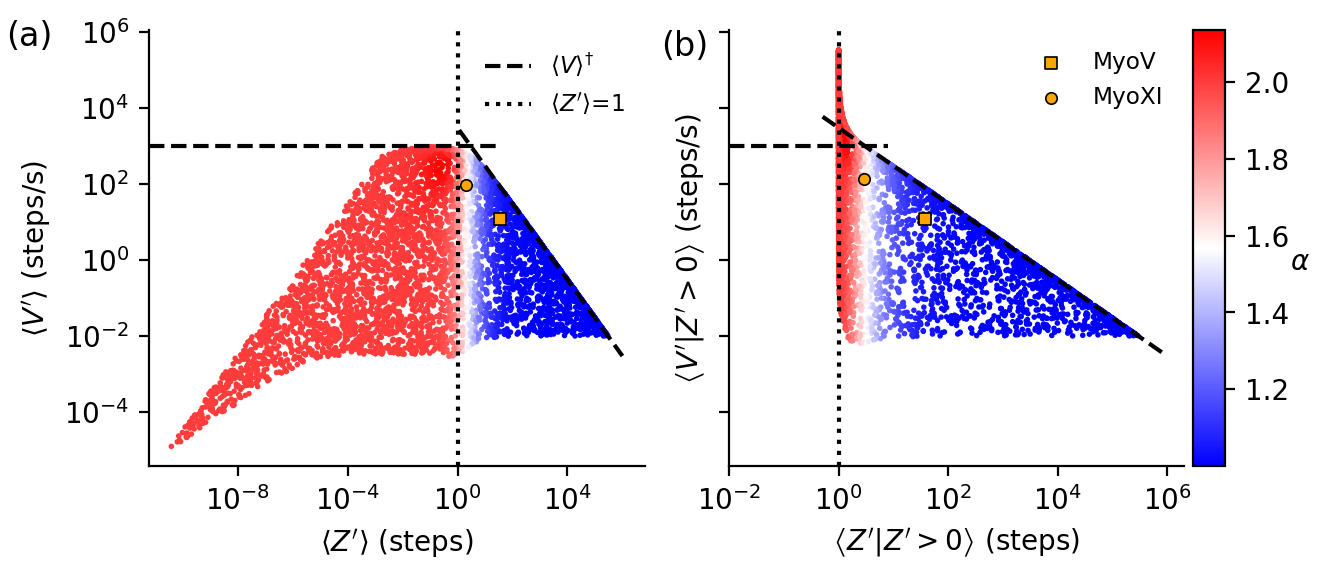

In [29]:
cmap = "bwr"

fig, axs = plt.subplots(1, 2, figsize=(column_width * 2, 3), sharey=True)
axs = axs.flatten()

ax = axs[0]
ax.plot(
    pareto_line_df.xdata[15:],
    pareto_line_df.ydata[15:],
    color="k",
    ls="--",
    label=r"$\left<V\right>^{\dagger}$",
)
ax.axhline(pareto_line_df.kfpp.values[0] / 3, xmax=0.7, color="k", ls="--")
ax.axvline(1, ls=":", color="k", label=r"$\left<Z^{\prime}\right>$=1")
ax_divider = make_axes_locatable(ax)
c = ax.scatter(
    pareto_vz_df.zrun, pareto_vz_df.vrun, s=1, c=pareto_vz_df.shapes, cmap=cmap
)

marker_size = 16
lw = 0.6
myoV_dot = ax.scatter(
    36.1,
    11.66,
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="s",
    s=marker_size,
)
myoXI_dot = ax.scatter(
    2.05, 93, facecolor="orange", edgecolor="black", linewidth=lw, marker="o", s=17
)

ax.legend(fontsize="small", loc=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\left<Z^{\prime}\right>$ (steps)")
ax.set_ylabel(r"$\left<V^{\prime}\right>$ (steps/s)")

ax = axs[1]
ax.plot(pareto_line_df.xdata[10:], pareto_line_df.ydata[10:], color="k", ls="--")
ax.axhline(pareto_line_df.kfpp.values[0] / 3, xmax=0.35, color="k", ls="--")
ax.axvline(1, ls=":", color="k")
ax_divider = make_axes_locatable(ax)
c = ax.scatter(
    pareto_vz_df.zrun2, pareto_vz_df.vrun2, s=1, c=pareto_vz_df.shapes, cmap=cmap
)
cax1 = ax_divider.append_axes("right", size="7%", pad="2%")
cbar = fig.colorbar(c, cax=cax1, ax=ax, orientation="vertical")
cax1.xaxis.set_ticks_position("top")

pT_myoV = 0.02392726299159987
pT_myoXI = 0.29255680444000576
myoV_dot_2 = ax.scatter(
    36.1 / (1 - pT_myoV),
    11.66 / (1 - pT_myoV),
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="s",
    s=marker_size,
    label="MyoV",
)
myoXI_dot_2 = ax.scatter(
    2.05 / (1 - pT_myoXI),
    93 / (1 - pT_myoXI),
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="o",
    s=17,
    label="MyoXI",
)

cbar.set_label(r"$\alpha$", rotation="horizontal")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=1e-2)
ax.set_xlabel(r"$\left<Z^{\prime}|Z^{\prime}>0\right>$ (steps)")
ax.set_ylabel(r"$\left<V^{\prime}|Z^{\prime}>0\right>$ (steps/s)")
ax.legend(fontsize="small", loc=1)

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath("pareto.pdf"), facecolor="w")
plt.show()

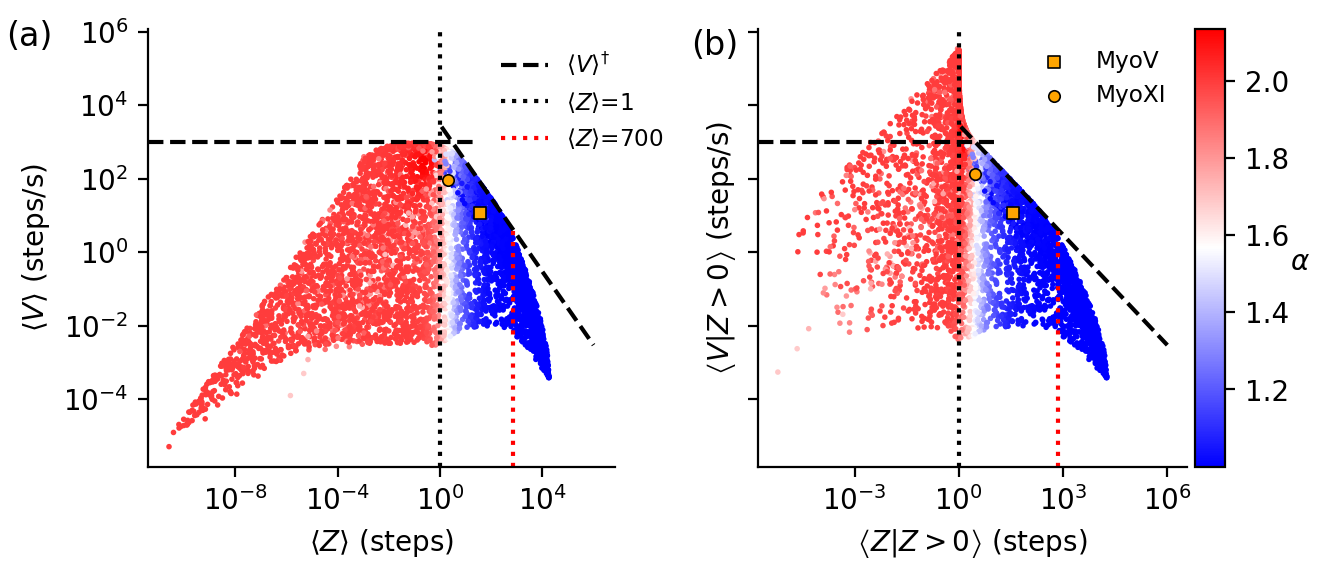

In [30]:
cmap = "bwr"

fig, axs = plt.subplots(1, 2, figsize=(column_width * 2, 3), sharey=True)
axs = axs.flatten()

ax = axs[0]
ax.plot(
    pareto_line_df.xdata[15:],
    pareto_line_df.ydata[15:],
    color="k",
    ls="--",
    label=r"$\left<V\right>^{\dagger}$",
)
ax.axhline(pareto_line_df.kfpp.values[0] / 3, xmax=0.7, color="k", ls="--")
ax.axvline(1, ls=":", color="k", label=r"$\left<Z\right>$=1")
ax.axvline(700, color="red", ls=":", ymax=0.55, label=r"$\left<Z\right>$=700")
ax_divider = make_axes_locatable(ax)
c = ax.scatter(
    pareto_vz_df.zrun_kd2,
    pareto_vz_df.vrun_kd2,
    s=1,
    c=pareto_vz_df.shapes_kd2,
    cmap=cmap,
)

marker_size = 16
lw = 0.6
myoV_dot = ax.scatter(
    36.1,
    11.66,
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="s",
    s=marker_size,
)
myoXI_dot = ax.scatter(
    2.05, 93, facecolor="orange", edgecolor="black", linewidth=lw, marker="o", s=17
)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\left<Z\right>$ (steps)")
ax.set_ylabel(r"$\left<V\right>$ (steps/s)")
ax.legend(fontsize="small", loc=1, bbox_to_anchor=(1.15, 1))

ax = axs[1]
ax_divider = make_axes_locatable(ax)
c = ax.scatter(
    pareto_vz_df.zrun2_kd2,
    pareto_vz_df.vrun2_kd2,
    s=1,
    c=pareto_vz_df.shapes_kd2,
    cmap=cmap,
)
cax1 = ax_divider.append_axes("right", size="7%", pad="2%")
cbar = fig.colorbar(c, cax=cax1, ax=ax, orientation="vertical")

ax.plot(pareto_line_df.xdata[15:], pareto_line_df.ydata[15:], color="k", ls="--")
ax.axhline(pareto_line_df.kfpp.values[0] / 3, xmax=0.55, color="k", ls="--")
ax.axvline(1, ls=":", color="k")
ax.axvline(700, color="red", ls=":", ymax=0.55)

pT_myoV = 0.02392726299159987
pT_myoXI = 0.29255680444000576

myoV_dot_2 = ax.scatter(
    36.1 / (1 - pT_myoV),
    11.66 / (1 - pT_myoV),
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="s",
    s=marker_size,
    label="MyoV",
)
myoXI_dot_2 = ax.scatter(
    2.05 / (1 - pT_myoXI),
    93 / (1 - pT_myoXI),
    facecolor="orange",
    edgecolor="black",
    linewidth=lw,
    marker="o",
    s=17,
    label="MyoXI",
)

cbar.set_label(r"$\alpha$", rotation="horizontal")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\left<Z|Z>0\right>$ (steps)")
ax.set_ylabel(r"$\left<V|Z>0\right>$ (steps/s)")
ax.legend(fontsize="small", loc=1)

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath("pareto2.pdf"), facecolor="w")
plt.show()

# Compare Observables from Different Optical Trap Modes

The following describes an empirical relationship exponential relationship between zruns and a liner relationship between vruns made observed in optical traps with a constant resistive force of zero and a compliant trap with force constant of 4.1 pN/nm.

In [33]:
if not figures.check_trapmode_data(path_figdata):
    figures.make_trapmode_data(path_figdata)

In [34]:
trapmode_fits_df = pd.read_csv(path_figdata.joinpath('trapmode_fits_data.csv'))
trapmode_vz_df = pd.read_csv(path_figdata.joinpath('trapmode_vz_data.csv'))

In [35]:
print('Zrun Exponent: ', trapmode_fits_df.zrun_exp.values[0])
print('Vrun Slope:', trapmode_fits_df.vrun_slope.values[0])
print('Vrun Intercept:', trapmode_fits_df.vrun_intercept.values[0])
print('Vrun r-value:', trapmode_fits_df.vrun_rvalue.values[0])

Zrun Exponent:  0.4739369566656272
Vrun Slope: 1.0353496713349166
Vrun Intercept: 0.4532590540288055
Vrun r-value: 0.9990110029776286


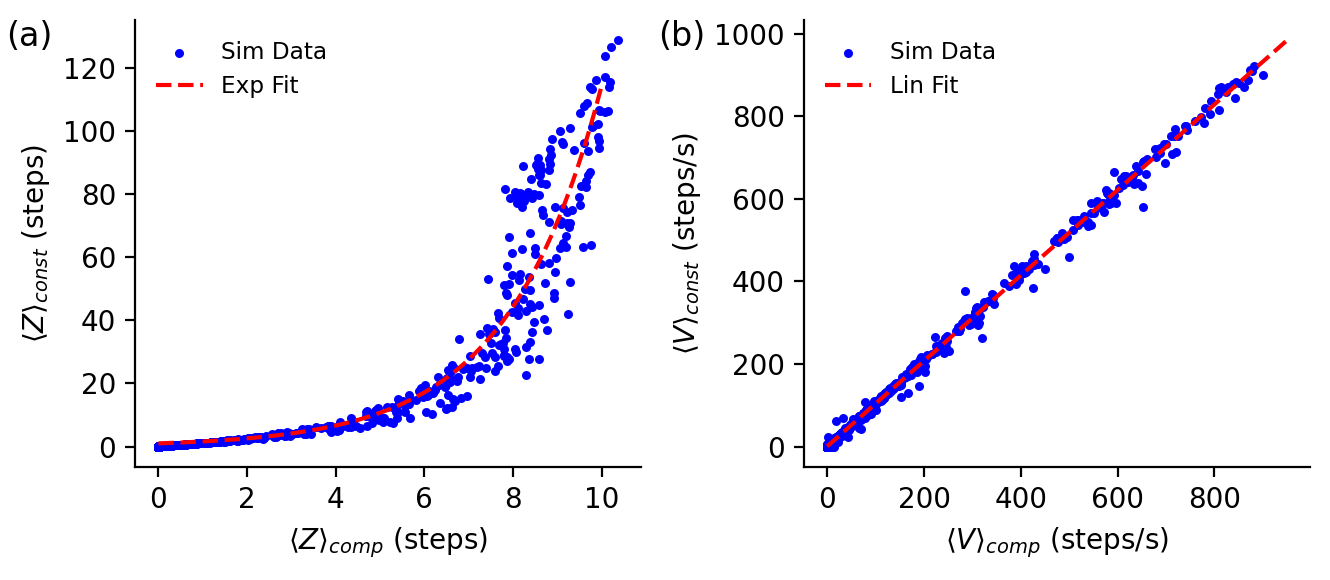

In [36]:
fig, axs = plt.subplots(1,2, figsize=(column_width*2,3))

axs = axs.flatten()
ax = axs[0]
ax.scatter(trapmode_vz_df.zrun_comp, trapmode_vz_df.zrun_const, s=5, color='blue', label='Sim Data')
ax.plot(trapmode_fits_df.zrun_xdata, trapmode_fits_df.zrun_ydata, c='r', ls='--', label='Exp Fit')
ax.set_xlabel(r'$\left<Z\right>_{comp}$ (steps)')
ax.set_ylabel(r'$\left<Z\right>_{const}$ (steps)')
ax.legend(fontsize='small')

ax = axs[1]
ax.scatter(trapmode_vz_df.vrun_comp, trapmode_vz_df.vrun_const, s=5, label= 'Sim Data', color='blue')
ax.plot(trapmode_fits_df.vrun_xdata, trapmode_fits_df.vrun_ydata, ls='--', c='r', label='Lin Fit')
ax.set_xlabel(r'$\left<V\right>_{comp}$ (steps/s)')
ax.set_ylabel(r'$\left<V\right>_{const}$ (steps/s)')
ax.legend(fontsize='small')

plt.tight_layout()
label_subplots(fig, axs)
plt.savefig(path_figures.joinpath('trapmode.pdf'), facecolor='w')